## **Customer shopping**

### Contents
1. Load data and check size
2. Drop unused columns
3. Check missing values, duplicates, and dtypes
4. Split by Gender
5. EDA — Item Purchased, Size, Category, Review Rating, Purchase Amount
6. Multivariate — correlation heatmap
7. Feature engineering — dummy variables, scaling, binning
8. Summary

In [90]:
# TODO: import pandas, numpy, matplotlib.pyplot, and seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [91]:
# TODO: load shopping_trends.csv with pd.read_csv(), then show the first 5 rows
df = pd.read_csv('shopping_trends.csv')

In [92]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [93]:
# TODO: check the dataset size with df.shape
df.shape

(3900, 19)

In [94]:
# TODO: drop the Customer ID column  
df = df.drop(columns='Customer ID')

In [95]:
df.head()

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


### **Data quality**

Check dtypes, missing values, and duplicate rows before plotting.

In [96]:
# TODO: check columns, dtypes, and non-null counts with df.info()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       3900 non-null   int64  
 1   Gender                    3900 non-null   str    
 2   Item Purchased            3900 non-null   str    
 3   Category                  3900 non-null   str    
 4   Purchase Amount (USD)     3900 non-null   int64  
 5   Location                  3900 non-null   str    
 6   Size                      3900 non-null   str    
 7   Color                     3900 non-null   str    
 8   Season                    3900 non-null   str    
 9   Review Rating             3900 non-null   float64
 10  Subscription Status       3900 non-null   str    
 11  Payment Method            3900 non-null   str    
 12  Shipping Type             3900 non-null   str    
 13  Discount Applied          3900 non-null   str    
 14  Promo Code Used    

In [97]:
# TODO: check missing values with df.isnull().sum()
df.isnull().sum()

Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [98]:
# TODO: check duplicate rows with df.duplicated().sum()
print(df.duplicated().sum())

0


In [99]:
# TODO: univariate — describe numeric columns
df.describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,25.351538
std,15.207589,23.685392,0.716223,14.447125
min,18.000000,20.000000,2.500000,1.000000
25%,31.000000,39.000000,3.100000,13.000000
50%,44.000000,60.000000,3.700000,25.000000
75%,57.000000,81.000000,4.400000,38.000000
max,70.000000,100.000000,5.000000,50.000000


In [100]:
# TODO: split the data into male_df and female_df using df[df['Gender']==...]
male_df = df[df['Gender'] == 'Male']
female_df = df[df['Gender'] == 'female']

In [101]:
male_df


,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2647,60,Male,Shoes,Footwear,58,South Carolina,M,Red,Summer,3.3,No,Debit Card,2-Day Shipping,No,No,25,Debit Card,Annually
2648,51,Male,Pants,Clothing,84,Illinois,M,Gray,Spring,3.9,No,Venmo,Next Day Air,No,No,14,PayPal,Bi-Weekly
2649,23,Male,Gloves,Accessories,21,Minnesota,M,Magenta,Fall,3.9,No,Credit Card,Store Pickup,No,No,14,Bank Transfer,Fortnightly
2650,20,Male,Socks,Clothing,35,Oregon,L,Maroon,Summer,4.2,No,PayPal,Standard,No,No,46,Credit Card,Every 3 Months


In [102]:
female_df

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases


## **EDA**

### **Item Purchased**

In [103]:
# TODO: count top items with value_counts().reset_index() for male, female, and all customers
# Đếm các mặt hàng được mua nhiều nhất cho từng nhóm nam, nữ
top_items_male = male_df['Item Purchased'].value_counts().reset_index()
top_items_male.columns = ['Item Purchased', 'Count']

top_items_female = female_df['Item Purchased'].value_counts().reset_index()
top_items_female.columns = ['Item Purchased', 'Count']

top_items_all = df['Item Purchased'].value_counts().reset_index()
top_items_all.columns = ['Item Purchased', 'Count']

In [104]:
top_items_male

,Item Purchased,Count
0,Pants,123
1,Jewelry,119
2,Sweater,114
3,Coat,114
4,Dress,114
5,Scarf,112
6,Shirt,110
7,Shorts,109
8,Skirt,109
9,Jacket,109


In [105]:
top_items_female

,Item Purchased,Count


In [106]:
top_items_all

,Item Purchased,Count
0,Blouse,171
1,Pants,171
2,Jewelry,171
3,Shirt,169
4,Dress,166
5,Sweater,164
6,Jacket,163
7,Coat,161
8,Sunglasses,161
9,Belt,161


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13432\2429145775.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13432\2429145775.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Giới tính", loc="best")  # thêm legend


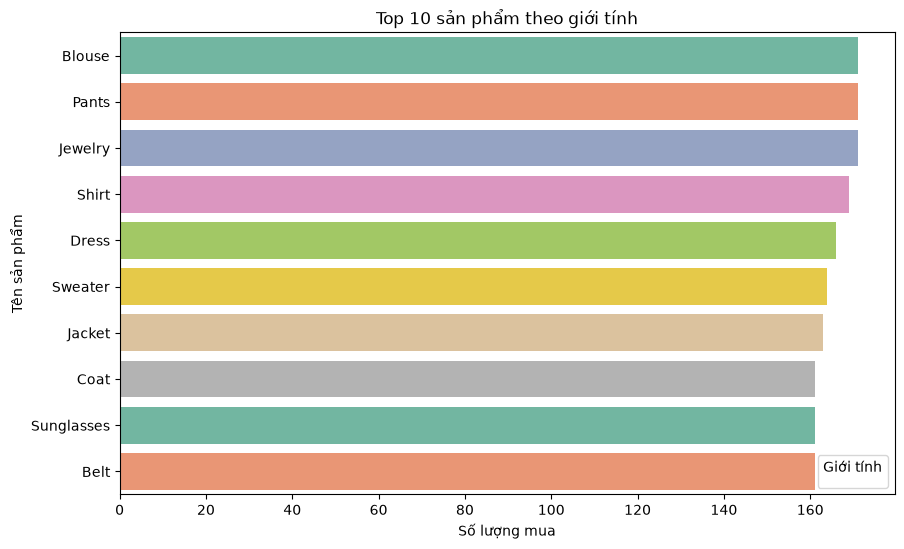

In [107]:
# TODO: plot a horizontal bar chart of the top 10 items with sns.barplot()
# vẽ biểu đồ thanh ngang (horizontal bar chart) cho top 10 sp

# lấy top 10 sp cho tất cả KH
top10_items = top_items_all.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data = top10_items,
    x="Count",               # trục X là số lượng
    y="Item Purchased",
    palette="Set2"
 )
plt.title("Top 10 sản phẩm theo giới tính")
plt.xlabel("Số lượng mua")
plt.ylabel("Tên sản phẩm")
plt.legend(title="Giới tính", loc="best")  # thêm legend
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13432\1909422088.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


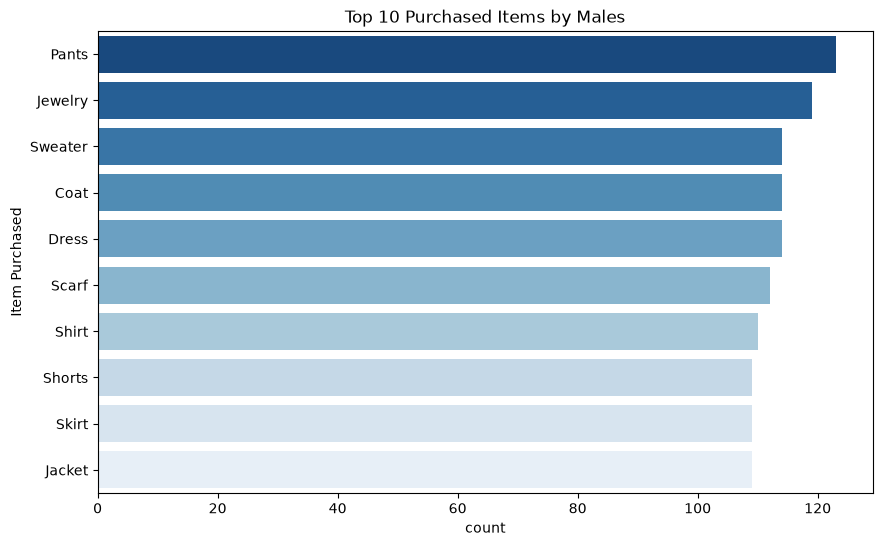

In [108]:
# TODO: plot a horizontal bar chart of the top 10 items for males with sns.barplot()
# vẽ biểu đồ thanh ngang cho 10 sp của KH nam
top10_items_male = top_items_male.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data = top10_items_male,
    x="Count",               # trục X là số lượng
    y="Item Purchased",      # trục Y là tên sản phẩm
    palette = "Blues_r"      # bảng màu (có thể đổi)
)
plt.title("Top 10 Purchased Items by Males")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()

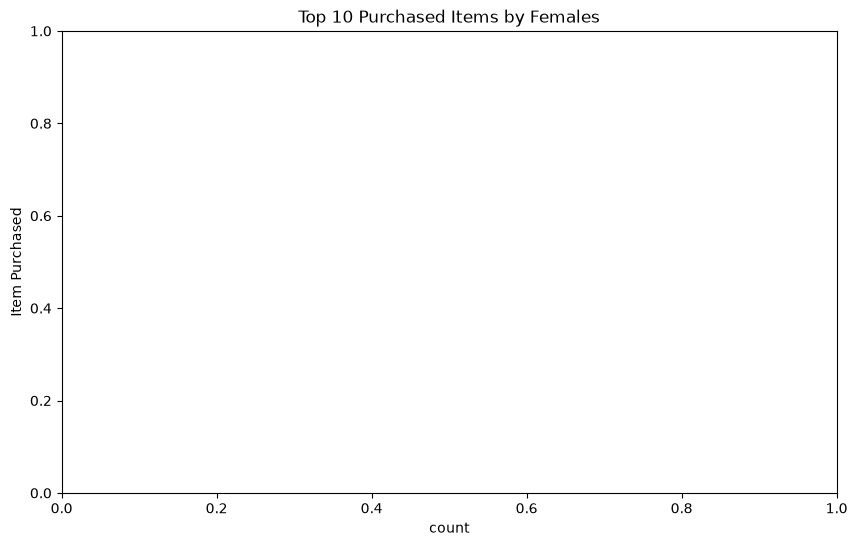

In [109]:
# TODO: plot a horizontal bar chart of the top 10 items for females with sns.barplot()
# vẽ biểu đồ thanh nganh cho top 10 sp của KH nữ
top10_items_female = top_items_female.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top10_items_female,
    y='Item Purchased',
    x='Count',
    hue='Item Purchased',
    palette= "Pinks_r",
    dodge=False,
    legend=False
)
plt.title("Top 10 Purchased Items by Females")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()

In [110]:
# TODO: count Size with value_counts() for all customers
# Để đếm số lượng theo cột Size cho tất cả khách hàng bằng value_counts()
size_counts = df['Size'].value_counts()

In [111]:
size_counts

Size
M     1755
L     1053
S      663
XL     429
Name: count, dtype: int64

In [112]:
# TODO: count Size with value_counts() for male_df and female_df
# Đếm Size cho khách hàng nam
size_counts_male = male_df['Size'].value_counts()
size_counts_male

Size
M     1165
L      716
S      476
XL     295
Name: count, dtype: int64

In [113]:
# Đếm Size cho khách hàng nữ
size_counts_female = female_df['Size'].value_counts()
size_counts_female

Series([], Name: count, dtype: int64)

### **Category**

In [114]:
# TODO: count Category with value_counts().reset_index() for all customers
# đếm số lượng theo Category cho tất cả khách hàng và chuyển thành DataFrame bằng reset_index()
ctg = df['Category'].value_counts().reset_index()
ctg.columns = ['Category', 'Count']

In [115]:
ctg

,Category,Count
0,Clothing,1737
1,Accessories,1240
2,Footwear,599
3,Outerwear,324


In [116]:
# TODO: count Category with value_counts().reset_index() for male_df and female_df
# đếm số lượng theo Category cho từng nhóm khách hàng nam 
ctg_male = male_df['Category'].value_counts().reset_index()
ctg_male.columns = ['Category', 'Count']
ctg_male

,Category,Count
0,Clothing,1181
1,Accessories,848
2,Footwear,400
3,Outerwear,223


In [117]:
# đếm số lượng theo Category cho từng nhóm khách hàng nữ
ctg_female = female_df['Category'].value_counts().reset_index()
ctg_female.columns = ['Category', 'Count']
ctg_female

,Category,Count


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13432\3045967276.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


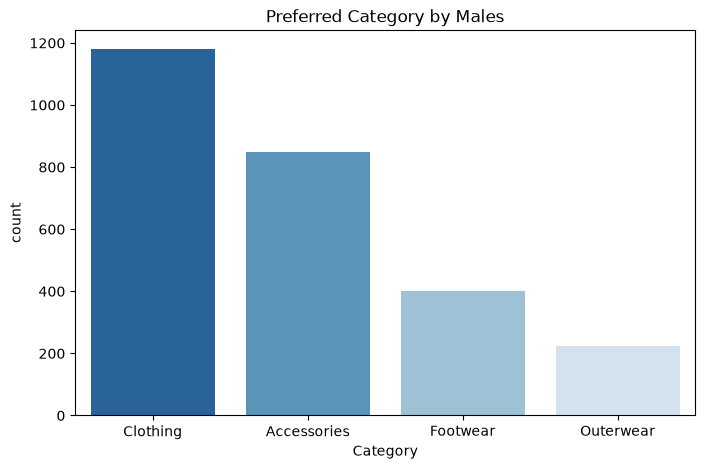

In [118]:
# TODO: plot a bar chart of preferred Category for males with sns.barplot()
# ẽ biểu đồ Preferred Category cho khách hàng nam với sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
    data=ctg_male,
    x='Category',      # trục X là tên Category
    y='Count',         # trục Y là số lượng
    palette="Blues_r"  # bảng màu cho nam
)
plt.title("Preferred Category by Males")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

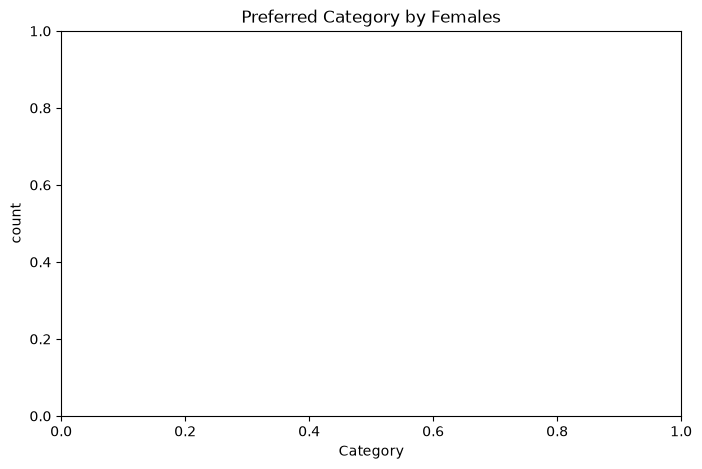

In [119]:
# TODO: plot a bar chart of preferred Category for females with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
   data = ctg_female,
   x = 'Category',
   y='Count',        
   palette="Reds_r"  
)
plt.title("Preferred Category by Females")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13432\4191628854.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Gender")


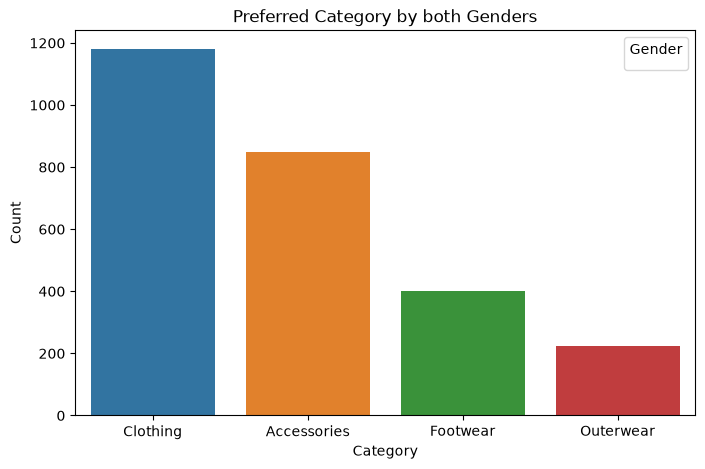

In [120]:
# TODO: plot a bar chart of preferred Category for both genders with sns.barplot()
# 
ctg_both = pd.concat([ctg_male, ctg_female])

plt.figure(figsize=(8, 5))
sns.barplot(
    data=ctg_both,
    x='Category',
    y='Count',
    hue='Category',
    dodge=False,
    legend=False
)
plt.title("Preferred Category by both Genders")
plt.xlabel('Category')
plt.ylabel('Count')
plt.legend(title="Gender")
plt.show()


In [121]:
# TODO: create waffle_data_m and waffle_data_f from Category value_counts()
waffle_data_m = dict(male_df['Category'].value_counts())


# TODO: create waffle_data_f from female_df['Category'].value_counts()
waffle_data_f = dict(female_df['Category'].value_counts())

ValueError: All wedge sizes are zero

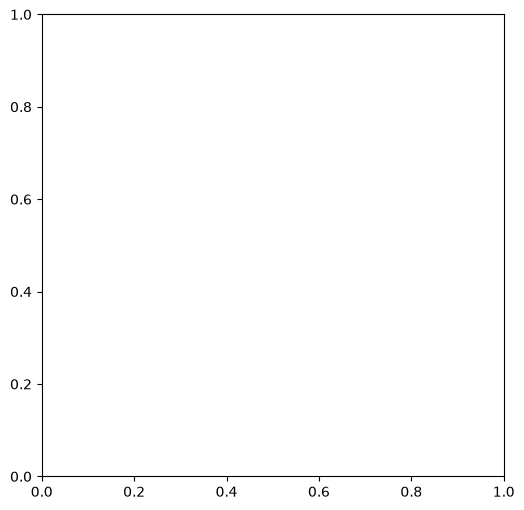

In [122]:
# TODO: plot a pie chart of preferred Category for females with plt.pie()
plt.figure(figsize=(6, 6))
plt.pie(
    female_df['Category'].value_counts(),
    labels=female_df['Category'].value_counts().index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Preferred Category by Females")
plt.show()

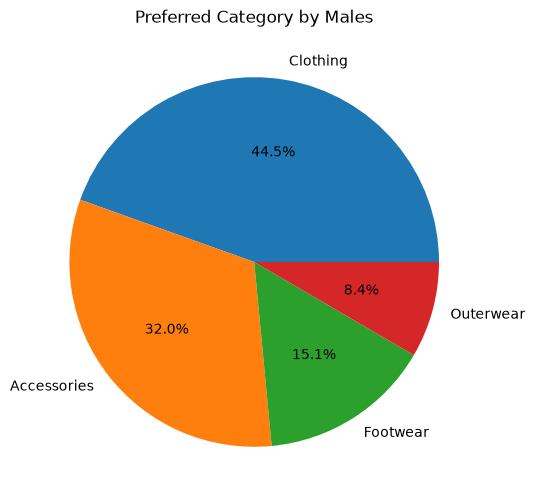

In [ ]:
# TODO: plot a pie chart of preferred Category for males with plt.pie()
plt.figure(figsize=(6, 6))
plt.pie(
    waffle_data_m.values(),
    labels=waffle_data_m.keys(),
    autopct='%1.1f%%'
)
plt.title("Preferred Category by Males")
plt.show() 

### **Review ratings**

In [ ]:
# TODO: filter female Clothing rows, then mean of Review Rating
# lọc các dòng nữ có Category = "Clothing"
cr_f = female_df[female_df['Category'] == 'Clothing']

# tính trung bình Review Rating
avg_cr_f = cr_f['Review Rating'].mean()

In [ ]:
# TODO: filter male Clothing rows, then mean of Review Rating
# lọc các dòng nam có Category = "Clothing"
cr_m = male_df[male_df['Category'] == 'Clothing']

# tính trung bình Review Rating
avg_cr_m = cr_m['Review Rating'].mean()

In [ ]:
print(avg_cr_m)
print(avg_cr_f)

3.7319220999153258
nan


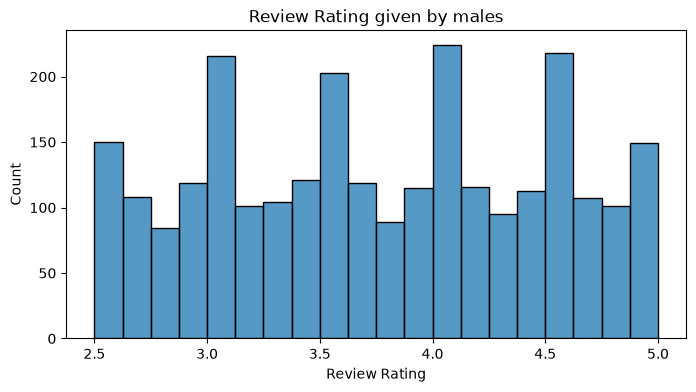

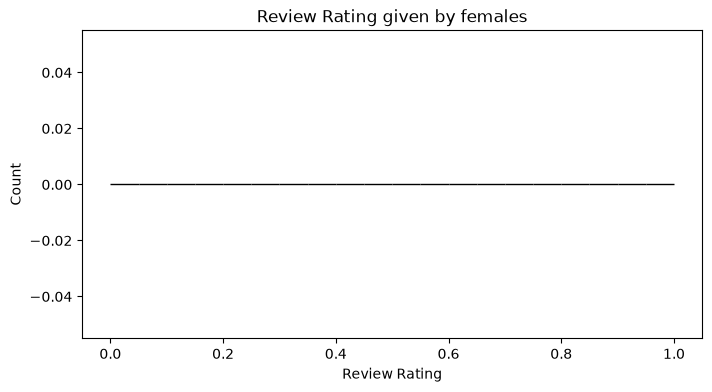

In [ ]:
# TODO: plot Review Rating histograms for males and females with sns.histplot()
# males
plt.figure(figsize=(8, 4))
sns.histplot(data=male_df, x='Review Rating', bins=20)
plt.title("Review Rating given by males")
plt.show()

# females
plt.figure(figsize=(8, 4))
sns.histplot(data=female_df, x='Review Rating', bins=20)
plt.title("Review Rating given by females")
plt.show()

In [ ]:
# TODO: count Review Rating with value_counts() for male Clothing (cr_m)
rating_counts_m = cr_m['Review Rating'].value_counts()

In [ ]:
# TODO: sum Purchase Amount (USD) for males
m_tpa = male_df['Purchase Amount (USD)'].sum()

# TODO: sum Purchase Amount (USD) for females
f_tpa = female_df['Purchase Amount (USD)'].sum()
print(m_tpa,"|",f_tpa)

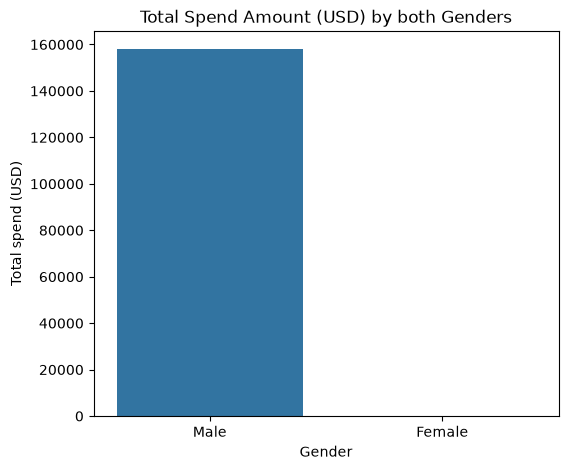

In [ ]:
# TODO: plot total spend by gender with sns.barplot()
total_spend = pd.DataFrame({
    'Gender': ['Male', 'Female'],'TotalSpend': [m_tpa, f_tpa]})
plt.figure(figsize=(6, 5))
sns.barplot(
    data=total_spend,
    x='Gender',
    y='TotalSpend'
)
plt.title("Total Spend Amount (USD) by both Genders")
plt.ylabel('Total spend (USD)')
plt.show()

In [ ]:
# TODO: filter female_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_f = cr_f
ca_f = female_df[female_df['Category'] == 'Accessories']
cf_f = female_df[female_df['Category'] == 'Footwear']
co_f = female_df[female_df['Category'] == 'Outerwear']

In [ ]:
# TODO: filter male_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_m = cr_m
ca_m = male_df[male_df['Category'] == 'Accessories']
cf_m = male_df[male_df['Category'] == 'Footwear']
co_m = male_df[male_df['Category'] == 'Outerwear']

In [ ]:
# TODO: create pcu dict from Promo Code Used value_counts()
pcu = dict(df['Promo Code Used'].value_counts())

### **Relationships (multivariate)**

Numeric columns only: Age, Purchase Amount (USD), Review Rating, Previous Purchases.

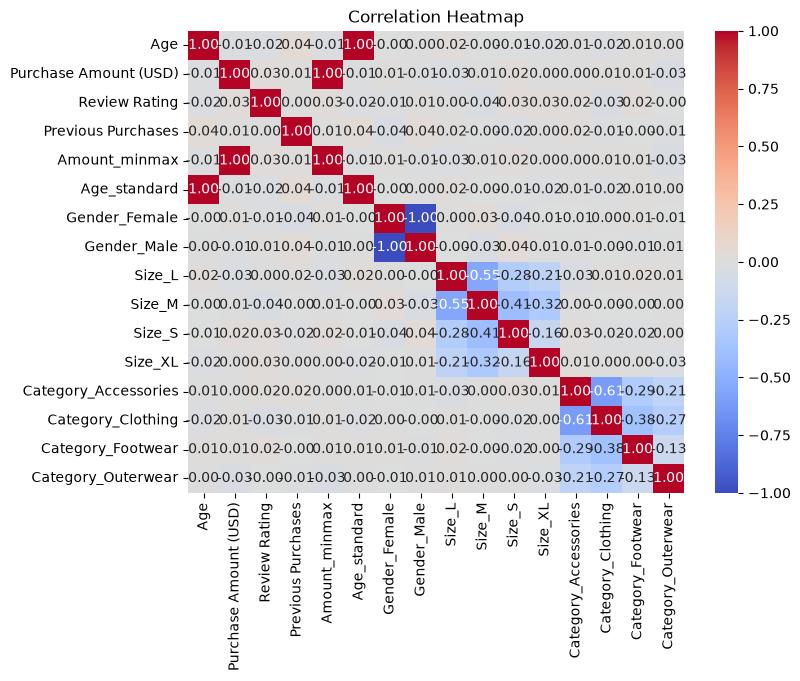

In [ ]:
# TODO: compute correlation with df.corr(numeric_only=True), then plot a heatmap with sns.heatmap()
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,        # hiển thị giá trị correlation trên ô
    cmap='coolwarm',   # màu sắc trực quan
    fmt=".2f"          # định dạng số thập phân
)
plt.title("Correlation Heatmap")
plt.show()

### **Feature engineering**

Dummy variables for columns with few levels. Scale numeric columns (keep originals). Bin purchase amount.

In [ ]:
# TODO: dummy variables for Gender, Size, and Category with pd.get_dummies()
df = pd.get_dummies(df, columns=['Gender', 'Size', 'Category'], dtype=int)
df.head()

,Age,Item Purchased,Purchase Amount (USD),Location,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,...,Gender_Female,Gender_Male,Size_L,Size_M,Size_S,Size_XL,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear
0,55,Blouse,53,Kentucky,Gray,Winter,3.1,Yes,Credit Card,Express,...,0,1,1,0,0,0,0,1,0,0
1,19,Sweater,64,Maine,Maroon,Winter,3.1,Yes,Bank Transfer,Express,...,0,1,1,0,0,0,0,1,0,0
2,50,Jeans,73,Massachusetts,Maroon,Spring,3.1,Yes,Cash,Free Shipping,...,0,1,0,0,1,0,0,1,0,0
3,21,Sandals,90,Rhode Island,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,...,0,1,0,1,0,0,0,0,1,0
4,45,Blouse,49,Oregon,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,...,0,1,0,1,0,0,0,1,0,0


In [ ]:
# TODO: use MinMaxScaler on Purchase Amount (USD) and StandardScaler on Age (keep original columns)

from sklearn.preprocessing import MinMaxScaler, StandardScaler
df['Amount_minmax'] = MinMaxScaler().fit_transform(df[['Purchase Amount (USD)']])
df['Age_standard'] = StandardScaler().fit_transform(df[['Age']])
df[['Purchase Amount (USD)', 'Amount_minmax', 'Age', 'Age_standard']].head()

,Purchase Amount (USD),Amount_minmax,Age,Age_standard
0,53,0.4125,55,0.718913
1,64,0.5500,19,-1.648629
2,73,0.6625,50,0.390088
3,90,0.8750,21,-1.517099
4,49,0.3625,45,0.061263


In [ ]:
# TODO: use pd.cut() to bin Purchase Amount (USD) into Low / Medium / High
df['Amount_bin'] = pd.cut(df['Purchase Amount (USD)'],bins=[0, 100, 500, float('inf')],labels=['Low', 'Medium', 'High'])

df['Amount_bin'].value_counts()

Amount_bin
Low       3900
Medium       0
High         0
Name: count, dtype: int64

### **Summary**

Write 4–5 insights from the plots. These are associations, not causal claims.

Examples to check:
- Which items and categories are most common for males vs females?
- Do males and females spend a similar total amount?
- Is Review Rating similar across genders?
- How often is a promo code used?

# TODO: write insights
- 
- 
- 
- 

Caveat: correlation is not causation.